# Write up: Monitoring ingested VIIRS active fire detection data quality

The FEDS production system relies on an archive of VIIRS active fire detections, which are currently stored as text files in the `gsfc_landslides/FEDSpreprocessed/SNPP` and `gsfc_landslides/FEDSpreprocessed/NOAA20` shared S3 buckets. 

As we move towards using this system to create more publication quality datasets, and continue to debug issues with the near real-time data ingest process, we needed to ensure that our archive is robust and that we are aware of any gaps in our data coverage. In particular, some of the team discovered [here](https://github.com/Earth-Information-System/fireatlas/issues/127) that, depending on what hour of the day we downloaded that day's VIIRS observations, we could silently miss parts of the globe that the source satellite had not yet orbited at that time. While we believe this issues has been addressed, irregular satellite orbits remain a source of potential error. 

To make our NRT data production more robust, I wanted to implement a function that would check for potential missing observations as data is ingested into our archive. As part of this process, I conducted a retrospective analysis of several years of VIIRS active fire detection data, created a system of regional alerting thresholds, and tuned the thresholds based on scientific and operational criteria. 

## Retrospective analysis  

### Initial checks 
- any missing files, or files of very small size?
- e.g. we downloaded the HTML authorization page

### The problem with a naive approach 

Unfortunately, checking for missing data is not as simple as simply looking to see if a file is empty or missing. As you can see in the image below, we have a failure case in which we have data for part of the globe, but not all of it. Just from file level statistics, this looks like a reasonable day of data- we see a fairly large variation in file size and total number of observations throughout the year, so it is not immediately obvious that this file is incomplete just from looking at the file size. 

![](viirs_mismatch_example.png)

### Longitude zones 
Because SNPP and NOAA20 are polar orbiting, I divided the globe into 9 longitude zones, where each zone encompasses a range of 40 degrees. If we lose data partway through the day for any reason, some of these zones may be empty. If we lose data halfway through a zone, we may still be able to notice that the number of VIIRS active fire observations for that day is a statistical outlier. 

### Alerting threshold
- .01 quintile
- DevOps issue of tuning alert frequency
- Retrospective analysis to determine quintiles

### Manual review of potential outliers 

## Results 

# Code - File level stats

In [2]:
# import glob
import os 
import re
import ast 
import pandas as pd 
import hvplot.pandas
import holoviews as hv
import geopandas as gpd
import cartopy.crs as ccrs 
from tqdm import tqdm
from shapely.geometry import Point 
import matplotlib.pyplot as plt

# hvplot.extension('bokeh')
# hv.extension('bokeh')


In [2]:
NOAA20_START = "2023-01-01"
NOAA20_STOP = "2024-9-20"

SNPP_START = "2018-01-01"
SNPP_STOP = "2024-9-20"

files_to_check = []

In [3]:
## Initial check: what days are we missing files for? 
## And, get stats about each file while we are opening them anyways

# # slow - load from file, don't re-run

# snpp = "/projects/shared-buckets/gsfc_landslides/FEDSpreprocessed/SNPP"
# noaa20 = "/projects/shared-buckets/gsfc_landslides/FEDSpreprocessed/NOAA20"

# data = []

# for sat in [snpp, noaa20]:
    
#     for filename in tqdm(os.listdir(sat)):

        # ensure filename vaguely correct
        # if not re.match(r'^\d{8}_(AM|PM)\.txt$', filename):
        #     print(f"*** Check {filename} ***")
        #     continue
            
#         fp = os.path.join(sat, filename)
#         size = os.path.getsize(fp)

#         try:
#             df = pd.read_csv(fp)
        # except Exception as e:
        #     files_to_check.append(os.path.join(sat.split('/')[:-1], filename))
        #     print(f"Exception while opening {filename}: {e}")

#         rows = len(df)

#         if "AM" in filename:
#             time = "AM"
#         elif "PM" in filename:
#             time = "PM"
#         else:
#             print(f"*** Check {filename} ***")
#             continue

#         data.append({'filename': filename, 
#                     'file size': size,
#                     'num observations': rows,
#                     'ampm': time,
#                     'sat': sat})

# df = pd.DataFrame(data) 

# df.to_csv('data_coverage_summary.csv', index=False)

In [4]:
df = pd.read_csv("~/notebooks/data_coverage_summary.csv")
df = df[df.filename != '.ipynb_checkpoints']
df['file_size_mb'] = df['file size'] / 1e6
df = df.drop(['file size'], axis=1)
df['sat'] = df['sat'].apply(os.path.basename)
# parse date from filename
df['date'] = df['filename'].str[:8]
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

# any missing days? 
count = 0
# check snpp: 2018-2023
snpp = df[df['sat'] == "SNPP"]
dates = pd.date_range(SNPP_START, SNPP_STOP)
for date in dates:
    observations = snpp[snpp['date'] == date]
    if len(observations) != 2: # AM and PM 
        count += 1
        print(f"Missing SNPP file(s) for {date}. {len(observations)} observations found.")

# check NOAA20: 2023-2023
noaa = df[df['sat'] == "NOAA20"]
dates = pd.date_range(NOAA20_START, NOAA20_STOP)
for date in dates:
    observations = noaa[noaa['date'] == date]
    if len(observations) != 2: 
        count += 1
        print(f"Missing NOAA20 file(s) for {date}. {len(observations)} observations found.")

print(f"{count} files missing total.")

Missing SNPP file(s) for 2024-05-29 00:00:00. 0 observations found.
Missing SNPP file(s) for 2024-05-30 00:00:00. 0 observations found.
Missing SNPP file(s) for 2024-06-01 00:00:00. 0 observations found.
Missing SNPP file(s) for 2024-06-02 00:00:00. 0 observations found.
Missing SNPP file(s) for 2024-06-03 00:00:00. 0 observations found.
Missing SNPP file(s) for 2024-06-04 00:00:00. 0 observations found.
Missing SNPP file(s) for 2024-07-11 00:00:00. 0 observations found.
Missing SNPP file(s) for 2024-07-12 00:00:00. 0 observations found.
Missing SNPP file(s) for 2024-07-13 00:00:00. 0 observations found.
Missing SNPP file(s) for 2024-07-14 00:00:00. 0 observations found.
Missing SNPP file(s) for 2024-07-15 00:00:00. 0 observations found.
Missing SNPP file(s) for 2024-07-16 00:00:00. 0 observations found.
Missing SNPP file(s) for 2024-07-17 00:00:00. 0 observations found.
Missing SNPP file(s) for 2024-07-18 00:00:00. 1 observations found.
Missing SNPP file(s) for 2024-07-23 00:00:00. 1 

array([[<Axes: title={'center': 'file_size_mb'}>]], dtype=object)

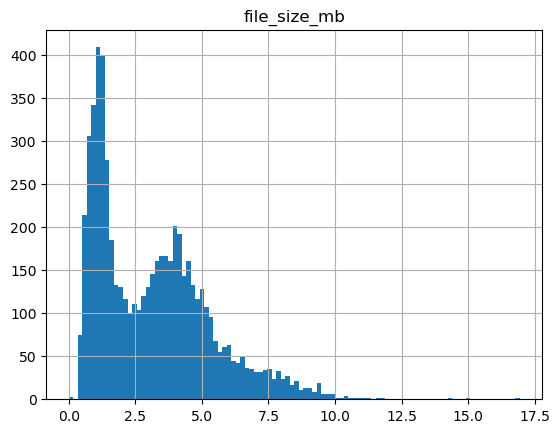

In [5]:
df.hist(['file_size_mb'], bins=100)

In [6]:
# check smallest N files 
df = df.sort_values('file_size_mb', axis=0, na_position='first')

# pd.reset_option('display.max_rows')
# pd.set_option('display.max_rows', None)
# display(df[df['ampm'] == 'AM'])

# should check 20 smallest files for AM and PM, and if the 20th
# is still funky, keep enlarging the window

for ampm in ["AM", "PM"]:
    for index, row in df[df['ampm'] == ampm].head(20).iterrows():
        files_to_check.append(os.path.join(row.sat, row.filename))

In [7]:
# use hvplot to plot am input number of observations from each sat in different colors, 
# per each day 
snpp_am = df[(df['sat'] == "SNPP") & (df['ampm'] == "AM")].hvplot.line(
    x='date',
    y='num observations', 
    color='blue', 
    title='Number of Active Fire Detections/Day (AM only)', 
    label='SNPP'
)

noaa20_am = df[(df['sat'] == "NOAA20") & (df['ampm'] == "AM")].hvplot.line(
    x='date',
    y='num observations', 
    color='green',
    label='NOAA20'
)

(snpp_am * noaa20_am)

:Overlay
   .Curve.SNPP   :Curve   [date]   (num observations)
   .Curve.NOAA20 :Curve   [date]   (num observations)

In [8]:
files_to_check.extend(["NOAA20/20220123_AM.txt", "NOAA20/20240204_AM.txt"])

In [9]:
snpp_pm = df[(df['sat'] == "SNPP") & (df['ampm'] == "PM")].hvplot.line(
    x='date',
    y='num observations', 
    color='blue', 
    title='Number of Active Fire Detections/Day (PM only)', 
    label='SNPP'
)

noaa20_pm = df[(df['sat'] == "NOAA20") & (df['ampm'] == "PM")].hvplot.line(
    x='date',
    y='num observations', 
    color='green',
    label='NOAA20'
)

(snpp_pm * noaa20_pm)

:Overlay
   .Curve.SNPP   :Curve   [date]   (num observations)
   .Curve.NOAA20 :Curve   [date]   (num observations)

In [10]:
# then, over day of year, plot five lines (e.g. one for each year) 
# with number of combined observations 

df = df.sort_values(by='date') # to display correctly 

df['day_of_year'] = df['date'].dt.dayofyear

years = [2018, 2019, 2020, 2021, 2022, 2023]

lines = [
    df[(df.date.dt.year == year) & (df.ampm == "PM")].hvplot.line(
    x='day_of_year', y='num observations', label=str(year)) for year in years

]

hv.Overlay(lines).opts(ylabel='Num observations (PM only)', xlabel='Day of year', title='# PM Observations by day of year')

:Overlay
   .Curve.A_2018 :Curve   [day_of_year]   (num observations)
   .Curve.A_2019 :Curve   [day_of_year]   (num observations)
   .Curve.A_2020 :Curve   [day_of_year]   (num observations)
   .Curve.A_2021 :Curve   [day_of_year]   (num observations)
   .Curve.A_2022 :Curve   [day_of_year]   (num observations)
   .Curve.A_2023 :Curve   [day_of_year]   (num observations)

In [11]:
average = df[df.sat == "SNPP"].groupby('day_of_year')['num observations'].mean().hvplot.line(title='Mean # of SNPP Observations per day of year, 2018-2024')

In [12]:
am_av = df[(df.sat == "SNPP") & (df.ampm == "AM")].groupby('day_of_year')['num observations'].mean().hvplot.line(label='AM Mean')
pm_av = df[(df.sat == "SNPP") & (df.ampm == "PM")].groupby('day_of_year')['num observations'].mean().hvplot.line(label='PM Mean')
(pm_av * am_av).opts(title="Mean # of SNPP Observations per day of year, 2018-2024")

:Overlay
   .Curve.PM_Mean :Curve   [day_of_year]   (num observations)
   .Curve.AM_Mean :Curve   [day_of_year]   (num observations)

In [13]:
hv.Layout([
    (pm_av * df[(df.sat == "SNPP") & (df.date.dt.year == year) & (df.ampm == "PM")].hvplot.line(
        x='day_of_year', y='num observations', label=str(year)).opts(title=f"# PM Observations, {year} vs. 6-year mean")) for year in years
]).cols(1)

:Layout
   .Overlay.I   :Overlay
      .Curve.PM_Mean :Curve   [day_of_year]   (num observations)
      .Curve.A_2018  :Curve   [day_of_year]   (num observations)
   .Overlay.II  :Overlay
      .Curve.PM_Mean :Curve   [day_of_year]   (num observations)
      .Curve.A_2019  :Curve   [day_of_year]   (num observations)
   .Overlay.III :Overlay
      .Curve.PM_Mean :Curve   [day_of_year]   (num observations)
      .Curve.A_2020  :Curve   [day_of_year]   (num observations)
   .Overlay.IV  :Overlay
      .Curve.PM_Mean :Curve   [day_of_year]   (num observations)
      .Curve.A_2021  :Curve   [day_of_year]   (num observations)
   .Overlay.V   :Overlay
      .Curve.PM_Mean :Curve   [day_of_year]   (num observations)
      .Curve.A_2022  :Curve   [day_of_year]   (num observations)
   .Overlay.VI  :Overlay
      .Curve.PM_Mean :Curve   [day_of_year]   (num observations)
      .Curve.A_2023  :Curve   [day_of_year]   (num observations)

# Code - Zonal stats

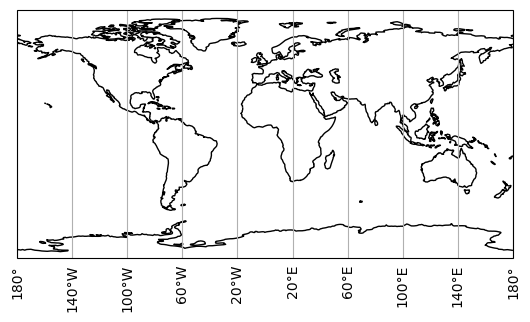

In [4]:
# show zones 

ZONE_SIZE = 40
ZONES = [i for i in range(-180, 181, ZONE_SIZE)]

zones = zones = [i for i in range(-180, 181, ZONE_SIZE)]
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.coastlines()

ax.gridlines(
    draw_labels=["x", "bottom"], 
    rotate_labels=True,
    xlocs=zones, 
    ylocs=[]
)

plt.show()

In [5]:
# Get number of points per zone per file

def points_in_zone(gdf, low, high):
    """
    Return count of how many points in the gdf 
    fall between the low and high longitude. 

    Zone bounds are given as a half open interval (low, high] 
    of longitude. 

    low < lon <= high
    """
    return len(gdf[(gdf['Lon'] > low) & (gdf['Lon'] <= high)])

def points_per_zone(gdf, zones):
    """
    Given a gdf and a list of zones, return a 
    list of how many points are in each zone of longitude. 

    Zones are defined by a list of lower bounds that define half 
    open intervals. For example, [-180, -140, -100] defines zones: 

    Zone 0 = < -180 (does not exist), 
    Zone 1 = (-180, -140]
    Zone 2 = (-140, -100]
    """
    # print("Longitude range: ", gdf.Lon.min(), "<--->", gdf.Lon.max())
    
    if isinstance(gdf, pd.DataFrame):
        geometry = [Point(xy) for xy in zip(gdf['Lon'], gdf['Lat'])]
        gdf = gpd.GeoDataFrame(gdf, geometry=geometry)
    
    counts = []
    for i in range(len(zones) - 1):
        # does not check east of last lower bound 
        low = zones[i]
        high = zones[i+1]
        counts.append(points_in_zone(gdf, low, high))
              
    return counts

def main(): 

    snpp = "/projects/shared-buckets/gsfc_landslides/FEDSpreprocessed/SNPP"
    noaa20 = "/projects/shared-buckets/gsfc_landslides/FEDSpreprocessed/NOAA20"
    
    data = []
    
    zones = [i for i in range(-180, 181, ZONE_SIZE)]
    print("Zones: ", zones)
    
    for sat in [snpp, noaa20]:
        
        for filename in tqdm(os.listdir(sat)):
    
            # ensure filename vaguely correct
            if not re.match(r'^\d{8}_(AM|PM)\.txt$', filename):
                print(f"*** Check {filename} ***")
                continue
                
            fp = os.path.join(sat, filename)
            size = os.path.getsize(fp)
    
            try:
                df = pd.read_csv(fp)
            except Exception as e:
                print(f"Exception while opening {filename}: {e}")
    
            rows = len(df)
    
            if "AM" in filename:
                time = "AM"
            elif "PM" in filename:
                time = "PM"
            else:
                print(f"*** Check {filename} ***")
                continue

            zone_counts = points_per_zone(df, zones)
    
            data.append({'filename': filename, 
                        'file size': size,
                        'num observations': rows,
                        'ampm': time,
                        'sat': sat,
                        'zone_counts': zone_counts})
    
    df = pd.DataFrame(data) 
    
    df.to_csv('zone_data_coverage_summary.csv', index=False)

# slow - run once
# main()

In [16]:
# Determine alerting thresholds 

df = pd.read_csv("/projects/notebooks/zone_data_coverage_summary.csv")

# Extract cols from string representation of list 
df.zone_counts = df.zone_counts.map(lambda x: ast.literal_eval(x))
for i in range(1, len(df.zone_counts[0]) + 1):
    df[f"zone{i}"] = df.zone_counts.apply(lambda x: x[i-1])

# print summary stats 
am = df[df['ampm'] == "AM"]
pm = df[df['ampm'] == "PM"]

zones = [f"zone{i}" for i in range(1, len(df.zone_counts[0]) + 1)]

def stats(df): 
    data = []
    for zone in zones:
        row = {
            'zone': zone,
            'min': df[zone].min(),
            'median': df[zone].median(), 
            'mean': df[zone].mean(),
            'max': df[zone].max(), 
            'std': df[zone].std(),
            'count_zero': df[zone].eq(0).sum(),
            'count_null': df[zone].isnull().sum(),
            '.01 quant': df[zone].quantile(.01),
            '.05 quant': df[zone].quantile(.05), 
            '.1 quant': df[zone].quantile(.1),
            '.9 quant': df[zone].quantile(.9),
            '.95 quant': df[zone].quantile(.95)
        }
        data.append(row)
    return data

In [17]:
am = pd.DataFrame(stats(am)).set_index('zone')
am

,min,median,mean,max,std,count_zero,count_null,.01 quant,.05 quant,.1 quant,.9 quant,.95 quant
zone,,,,,,,,,,,,
zone1,0,2.0,59.554829,8611,282.164719,1161,0,0.00,0.00,0.0,83.1,285.00
zone2,0,382.5,1419.589720,80353,3440.623027,8,0,27.00,56.00,81.0,3620.2,6699.05
zone3,0,1154.0,1582.852960,61034,1977.979104,9,0,150.27,267.00,363.9,2883.3,3981.40
zone4,0,510.0,1294.744237,26756,2215.969247,8,0,40.00,77.00,114.0,3335.1,4817.75
zone5,5,917.0,1317.410280,6975,1142.666375,0,0,138.18,218.00,306.0,2987.3,3852.30
zone6,36,2607.5,3131.259190,20823,2125.147395,0,0,377.18,693.90,958.0,6029.5,7251.20
zone7,0,740.0,1325.590031,19490,1569.951352,4,0,103.00,162.00,211.0,3466.8,4490.50
zone8,0,1590.0,2465.220561,43819,3157.603023,12,0,175.09,349.45,498.6,4969.1,7528.75
zone9,0,259.0,565.568224,23992,1178.341955,6,0,15.09,47.00,73.9,1165.4,1883.20


In [18]:
pm = pd.DataFrame(stats(pm)).set_index('zone')
pm

,min,median,mean,max,std,count_zero,count_null,.01 quant,.05 quant,.1 quant,.9 quant,.95 quant
zone,,,,,,,,,,,,
zone1,0,1.0,75.780480,7381,401.049928,1560,0,0.00,0.0,0.0,80.0,293.5
zone2,0,443.0,1141.665731,22005,1967.255940,22,0,34.12,93.0,133.0,2682.0,5007.3
zone3,0,3137.0,3568.752417,17432,2372.960556,16,0,456.20,840.3,1057.0,6717.6,8044.7
zone4,0,1319.0,2760.889928,30978,3475.098435,15,0,117.24,258.3,344.6,7386.2,9825.6
zone5,0,8112.0,9380.558466,52844,5938.683489,10,0,1261.02,2327.7,3088.0,17672.0,20839.8
zone6,0,13712.0,15875.702838,68957,10213.715953,8,0,1497.18,3125.6,4332.2,30864.2,35810.0
zone7,0,1313.0,2769.942937,35188,3292.210570,8,0,157.00,261.0,348.6,7755.2,9676.9
zone8,0,3668.0,4514.534456,34240,3417.726640,7,0,564.14,1060.5,1441.8,8816.4,10849.5
zone9,0,565.0,911.015279,19697,1150.305294,7,0,33.06,77.3,117.0,1971.4,2992.6


In [7]:
# use the .01 quantile as an alerting threshold 

class LongitudeZone:
    def __init__(self, zone_id, min_long, max_long, am_threshold, pm_threshold):
        self.id = zone_id          # ID or zone number
        self.min_long = min_long        # Minimum longitude
        self.max_long = max_long        # Maximum longitude
        self.am_threshold = am_threshold  # < threshold active fire observations triggers an alert
        self.pm_threshold = pm_threshold  # higher expectation for PM observations 

zones = [
    LongitudeZone(1, -180, -140, 0.00, 0.00), 
    LongitudeZone(2, -140, -100, 27.00, 34.12),
    LongitudeZone(3, -100, -60, 150.27, 456.20),
    LongitudeZone(4, -60, -20, 40.00, 117.24), 
    LongitudeZone(5, -20, 20, 138.18, 1261.02),
    LongitudeZone(6, 20, 60, 377.18, 1497.18),
    LongitudeZone(7, 60, 100, 103.00, 157.00),
    LongitudeZone(8, 100, 140, 175.09, 564.14), 
    LongitudeZone(9, 140, 180, 15.09, 33.06)
]

def alert(gdf, zones, ampm)->bool:
    """
    Determines if any one zone has fewer observations that the defined 
    alerting threshold. 

    Returns (bool, int, int):
        - True if alert triggered, else False 
        - Zone triggered, else None
        - Number of observations in triggered zone, else None

    gdf: geodataframe with VIIRS active fire detections for one day
        Expects columns 'ampm', 'Lat', 'Lon' 
    """

    for zone in zones:

        if ampm == "AM":
            am = points_in_zone(gdf[gdf['ampm'] == "AM"], zone.min_long, zone.max_long)
            if am < zone.am_threshold:
                print(f"Zone {zone.id} under threshold: {am} points observed < {zone.am_threshold}")
                return (True, zone.id, am) 
        elif ampm == "PM":
            pm = points_in_zone(gdf[gdf['ampm'] == "PM"], zone.min_long, zone.max_long)
            if pm < zone.pm_threshold:
                print(f"Zone {zone.id} under threshold: {pm} points observed < {zone.pm_threshold}")
                return (True, zone.id, pm) 
        else: 
            raise ValueError("Select AM or PM.")

    return (False, None, None)  



In [20]:
def find_alerts():
    snpp = "/projects/shared-buckets/gsfc_landslides/FEDSpreprocessed/SNPP"
    noaa20 = "/projects/shared-buckets/gsfc_landslides/FEDSpreprocessed/NOAA20"
    
    alerts = {}
    
    for sat in [snpp, noaa20]:
        
        for filename in tqdm(os.listdir(sat)): 
            
            # ensure filename vaguely correct
            if not re.match(r'^\d{8}_(AM|PM)\.txt$', filename):
                print(f"*** Check {filename} ***")
                continue
    
            try:
                df = pd.read_csv(os.path.join(sat, filename))
                gdf = gpd.GeoDataFrame(df, geometry=[Point(xy) for xy in zip(df['Lon'], df['Lat'])])
                ampm = "AM" if "AM" in filename else "PM"
                res = alert(gdf, zones, ampm)
                if res[0]:
                    alerts[os.path.join(sat, filename)] = res
                    print(filename)
            except Exception as e:
                print(f"Exception while opening {filename}: {e}")

    
    df = pd.DataFrame.from_dict(alerts, orient='index', columns=['alert', 'zone', 'num'])
    df = df.reset_index()
    df['sat'] = df['index'].str.split('/').str[-2]
    df['src_file'] = df['index'].str.split('/').str[-1]
    df = df.drop(['alert', 'index'], axis=1)
    df.to_csv('coverage_alerts')
# slow - run once 
# find_alerts()

In [8]:
# define utility functions 

def show_zonespoints(filename, alerted_zone, num_observations): 
    df = pd.read_csv(os.path.join("/projects/shared-buckets/gsfc_landslides/FEDSpreprocessed", filename))
    geometry = [Point(xy) for xy in zip(df['Lon'], df['Lat'])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry)

    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()
    ax.coastlines()

    ax.gridlines(
        draw_labels=["x", "bottom"], 
        rotate_labels=True,
        xlocs=ZONES, 
        ylocs=[]
    )

    gdf.plot(color='red', ax=ax, transform=ccrs.PlateCarree(), markersize=1)
    ampm = "AM" if "AM" in filename else "PM"
    threshold = zones[alerted_zone - 1].am_threshold if "AM" in filename else zones[alerted_zone - 1].pm_threshold
    title = f"{filename}: {num_observations} observations below {threshold} req for zone {alerted_zone}"
    ax.set_title(title)
    ax.axvspan(ZONES[alerted_zone-1], ZONES[alerted_zone-1] + ZONE_SIZE, facecolor='y', alpha=0.25)
    
    # plt.savefig(os.path.join('coverage_checks', filename.split('.')[0]))
    # plt.close()
    plt.show()

    # return gdf.plot(color='red', ax=ax, transform=ccrs.PlateCarree(), markersize=1).set_title(filename)

def save_zonespoints(filename, alerted_zone, num_observations): 
    df = pd.read_csv(os.path.join("/projects/shared-buckets/gsfc_landslides/FEDSpreprocessed", filename))
    geometry = [Point(xy) for xy in zip(df['Lon'], df['Lat'])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry)

    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()
    ax.coastlines()

    ax.gridlines(
        draw_labels=["x", "bottom"], 
        rotate_labels=True,
        xlocs=ZONES, 
        ylocs=[]
    )

    gdf.plot(color='red', ax=ax, transform=ccrs.PlateCarree(), markersize=1)

    ampm = "AM" if "AM" in filename else "PM"
    threshold = zones[alerted_zone - 1].am_threshold if "AM" in filename else zones[alerted_zone - 1].pm_threshold
    title = f"{filename}: {num_observations} observations below {threshold} req for zone {alerted_zone}"
    ax.set_title(title)
    ax.axvspan(ZONES[alerted_zone-1], ZONES[alerted_zone-1] + ZONE_SIZE, facecolor='y', alpha=0.25)
    
    plt.savefig(os.path.join('coverage_checks', filename.split('.')[0]))
    plt.close()
    # plt.show()

    # return gdf.plot(color='red', ax=ax, transform=ccrs.PlateCarree(), markersize=1).set_title(filename)

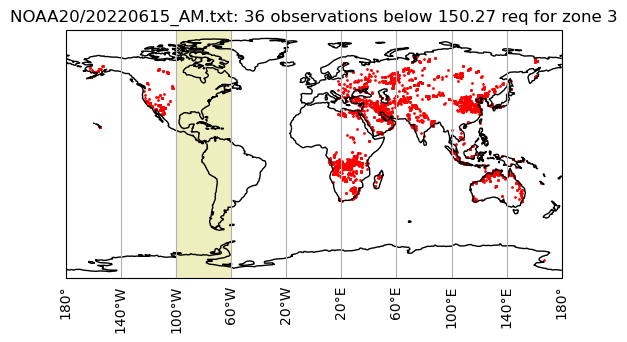

In [9]:
# example plot
show_zonespoints("NOAA20/20220615_AM.txt", alerted_zone=3, num_observations=36)


In [23]:
def save_plots_to_inspect():
    """
    Generates plots of alerted files with the zone 
    that caused the alert (by being under threshold) 
    highlighted and all points plotted, with zone lines. 
    """
    os.makedirs('coverage_checks/SNPP', exist_ok=True)
    os.makedirs('coverage_checks/NOAA20', exist_ok=True)
    
    for index, row in alerts.iterrows():
        filename = os.path.join(row.sat, row.src_file)
        save_zonespoints(filename, row.zone, row.num)
        print(f"Saved {os.path.join(row.sat, row.src_file)}")

# Slow, run once
# save_plots_to_inspect

In [24]:
alerts = pd.read_csv('/projects/notebooks/coverage_alerts.csv', index_col=0)
alerts['date'] = pd.to_datetime(alerts['src_file'].str[:8], format='%Y%m%d')
alerts['month'] = alerts['date'].dt.month
avg_alerts_per_month = alerts.groupby('month').size() / alerts['date'].dt.year.nunique()
avg_alerts_per_month

month
1     6.285714
2     4.571429
3     3.285714
4     5.714286
5     6.428571
6     2.428571
7     1.857143
8     1.857143
9     2.571429
10    5.714286
11    3.857143
12    7.142857
dtype: float64

In [25]:
avg_alerts_per_month.mean()


4.309523809523809

# Coverage checks
At this point, we have saved plots of each zone that would have been alerted under the .01 quantile threshold out to a `coverage_checks` directory. 

In [26]:
# !tar -czvf coverage_checks.tar.gz coverage_checks/

Manual inspection reveals that the following files have issues: 

NOAA20: 

In [27]:
noaa20_issues = [
"20220406_PM",
"20220615_AM",
"20220615_PM",
"20230225_AM",
"20230225_PM",
"20230505_PM",
"20230511_PM",
"20230611_PM",
"20230929_AM",
"20230929_PM",
"20240101_AM",
"20240121_AM",
"20240203_AM",
"20240203_PM",
"20240204_AM",
"20240204_PM",
"20240327_AM",
"20240327_PM",
"20240502_PM",
"20240527_AM",
"20240527_PM",
"20240531_AM",
"20240531_PM",
"20240914_AM",
"20240914_PM",
"20241002_AM",
"20241002_PM"
]

In [28]:
print(f"{len(noaa20_issues)} out of 47 files that triggered alerts were manually determined to be missing data")

27 out of 47 files that triggered alerts were manually determined to be missing data


In [29]:
snpp_issues = [
    "20180213_PM",
    "20190121_AM",
    "20190121_PM",
    "20191031_PM",
    "20191031_PM",
    "20210803_AM",
    "20210803_PM", 
    "20210804_AM", 
    "20210804_PM", 
    "20210805_PM", 
    "20230335_AM", 
    "20230225_PM", 
    "20230511_AM", 
    "20230726_AM", 
    "20230726_PM", 
    "20231101_AM", 
    "20231101_PM", 
    "20231102_AM", 
    "20231102_PM", 
    "20240131_AM", 
    "20240131_PM", 
    "20240327_AM", 
    "20240327_PM", 
    "20240424_PM", 
    "20240528_AM", 
    "20240528_PM", 
    "20240531_AM", 
    "20240531_PM", 
    "20240110_AM", 
    "20240710_PM",
    "20240718_AM", 
    "20240719_PM", 
    "20240724_AM", 
    "20240724_PM", 
    "20240730_PM", 
    "20240801_AM", 
    "20240802_AM", 
    "20240802_PM", 
    "20240914_AM", 
    "20240914_PM", 
    "20240924_AM", 
    "20240924_PM"
    
]

print(f"{len(snpp_issues)} out of 315 files that triggered alerts were manually determined to be missing data")

42 out of 315 files that triggered alerts were manually determined to be missing data


In [30]:
print(f"Zonal analysis + manual review indicates that \
{42 + 37} files are partially incomplete. \nThis is in addition \
to 60 missing files within the date range examined ({NOAA20_START} to {NOAA20_STOP} for NOAA20 and {SNPP_START} to {SNPP_STOP} for SNPP).") 

Zonal analysis + manual review indicates that 79 files are partially incomplete. 
This is in addition to 60 missing files within the date range examined (2023-01-01 to 2024-9-20 for NOAA20 and 2018-01-01 to 2024-9-20 for SNPP).


In [31]:
total_files = 2 * abs((pd.to_datetime(NOAA20_STOP) - pd.to_datetime(NOAA20_START)).days) + 2 * abs((pd.to_datetime(SNPP_STOP) - pd.to_datetime(SNPP_START)).days)
print(f"{(79 / total_files) * 100:.2f}% of the {total_files} files are affected")

1.28% of the 6164 files are affected
